## Аминокислотные последовательности антител

<img src="https://i0.wp.com/www.blopig.com/blog/wp-content/uploads/2013/07/Antibody1.png?ssl=1" style="background:white" width="600"/>

Как и любые белки́, [антитела](https://ru.wikipedia.org/wiki/%D0%90%D0%BD%D1%82%D0%B8%D1%82%D0%B5%D0%BB%D0%B0) состоят из [аминокислот](https://shorturl.at/Wc6V4), соединённых пептидными связями.

Каждой аминокислоте соответствует однобуквенный код (A - аланин, C - цистеин, D - аспартат, и т.д.), поэтому мы можем компактно записывать первичную структуру белков (то есть просто цепочку аминокислот) в виде строк.

Сегодня нам предстоит решить две задачи:
1. Обучить модель-классификатор, позволяющую по аминокислотной последовательности понять, из какого животного было получено антитело
2. Обучить модель-генератор новых антител с условием на биологический вид

#### Подготовим данные

В нашем наборе данных присутствуют антитела (точнее - небольшие фрагменты тяжелых цепей антител, VH-домены, непосредственно участвующие в связывании инородных молекул - антигенов), полученные из образцов пяти биологических видов: человек, макака-резус, мышь, кролик и верблюд.

In [37]:
import pandas as pd

antibodies = pd.read_csv("antibodies.csv").sample(frac=1.0)
antibodies.head(10)

,sequence,species
2280,SVKVSCKTSGYIFISHGISWVRQAPGQGLEWMGWVSAYNGNTSYAQ...,Mouse
4790,QEHLKESGGGLVQPGGSLKLSCKASGFTLSSYYMNWVRQAPGKGLE...,Rabbit
1432,HVQLVESGGGSVQAGGSLRLSCAASGSTYSTYCMGWYRQGPGKERE...,Camel
1680,HVQLVESGGGSVQTGGSLRLTCVASGNINKEYCMGWTRLVPGKERE...,Camel
2073,SVKVSCKASGYSFIDYYMHWVKQAPGKGLEWMGLVDPEDGDTIYAE...,Mouse
3280,QLQLQESGPGLVKPSETLSVTCAVSGGSISSSYWSWIRQAPGKGLE...,Rhesus
2810,SVKVSCKASGGTFSADAFSWVRQAPGQGLEWMGRIIPILGSANYAQ...,Mouse
4710,QSLEESGGDMVKPGASLTLTCTASGFSFSTNYYICWVRQAPGKGPE...,Rabbit
914,EVQLQQSGAELVRPGSSVKMSCKTSAYTFTSYGINWVKQRPGQGLE...,Human
2660,SVKVSCKASGGSFSHYAISWVRQAPGQGLEWMGGIIPIFGTPNYAQ...,Mouse


Создадим словари для аминокислот, специальных токенов и биологических видов:

In [38]:
SPECIAL_TOKENS = "_?\n"
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWYX"
VOCAB = {char: i for i, char in enumerate(SPECIAL_TOKENS + AMINO_ACIDS)}
SPECIES = {name: i for i, name in enumerate(sorted(antibodies["species"].unique()))}
SPECIES

{'Camel': 0, 'Human': 1, 'Mouse': 2, 'Rabbit': 3, 'Rhesus': 4}

In [66]:
ANTISPECIES = {i: name for i, name in enumerate(SPECIES)}
ANTISPECIES

{0: 'Camel', 1: 'Human', 2: 'Mouse', 3: 'Rabbit', 4: 'Rhesus'}

In [39]:
VOCAB

{'_': 0,
 '?': 1,
 '\n': 2,
 'A': 3,
 'C': 4,
 'D': 5,
 'E': 6,
 'F': 7,
 'G': 8,
 'H': 9,
 'I': 10,
 'K': 11,
 'L': 12,
 'M': 13,
 'N': 14,
 'P': 15,
 'Q': 16,
 'R': 17,
 'S': 18,
 'T': 19,
 'V': 20,
 'W': 21,
 'Y': 22,
 'X': 23}

In [40]:
ANTIVOCAB = {i: char for i, char in enumerate(VOCAB)}
SPECIAL_NUMBERS = list(map(lambda x: VOCAB[x], SPECIAL_TOKENS))
SPECIAL_NUMBERS, ANTIVOCAB

([0, 1, 2],
 {0: '_',
  1: '?',
  2: '\n',
  3: 'A',
  4: 'C',
  5: 'D',
  6: 'E',
  7: 'F',
  8: 'G',
  9: 'H',
  10: 'I',
  11: 'K',
  12: 'L',
  13: 'M',
  14: 'N',
  15: 'P',
  16: 'Q',
  17: 'R',
  18: 'S',
  19: 'T',
  20: 'V',
  21: 'W',
  22: 'Y',
  23: 'X'})

In [41]:
antibodies['seq_length'] = antibodies['sequence'].str.len()
max_lengths = antibodies.groupby('species')['seq_length'].max()
max_length_dict = max_lengths.to_dict()
max_length_dict

{'Camel': 141, 'Human': 125, 'Mouse': 119, 'Rabbit': 129, 'Rhesus': 130}

In [42]:
def decode_tokens(encoded: list[int], remove_special_tokens: bool = False) -> str:
        return ''.join(
            [
                ANTIVOCAB[idx]
                for idx in encoded
                if (idx not in SPECIAL_NUMBERS) or not remove_special_tokens
            ]
        )

In [43]:
import torch
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset, random_split


class AntibodiesDataset(Dataset):
    def __init__(self, df: pd.DataFrame) -> None:
        self.sequences = [
            [1] + [VOCAB[char] for char in s] + [2] for s in df["sequence"]
        ]
        self.labels = [SPECIES[label] for label in df["species"]]

    def __getitem__(self, index: int) -> tuple[list[int], int]:
        return self.sequences[index], self.labels[index]

    def __len__(self) -> int:
        return len(self.sequences)

    @staticmethod
    def collate_fn(batch: list[tuple[list[int], int]]) -> tuple[Tensor, Tensor]:
        encoded, lang_ids = zip(*batch)
        max_len = max(map(len, encoded))
        x = torch.zeros((len(encoded), max_len), dtype=int)
        for i, seq in enumerate(encoded):
            x[i, : len(seq)] = torch.tensor(seq)

        return x, torch.tensor(list(lang_ids))


labels = sorted(antibodies["species"].unique())
dataset = AntibodiesDataset(antibodies)
train_dataset, test_dataset = random_split(
    dataset, [4500, 500], torch.Generator().manual_seed(42)
)
print("Train size: ", len(train_dataset))
print("Test size: ", len(test_dataset))

Train size:  4500
Test size:  500


In [44]:
train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, collate_fn=dataset.collate_fn
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, collate_fn=dataset.collate_fn
)

#### Задание 1 (6 баллов). Классификация антител по биологическим видам

Мы начнём с нашей рекуррентной ячейки с последней практики:

In [45]:
class RNNCell(nn.Module):
    """
    (x_{t}, h_{t-1}) -> h_{t}
    """

    def __init__(self, input_dim: int, hidden_dim: int) -> None:
        super().__init__()
        self.linear = nn.Linear(input_dim + hidden_dim, hidden_dim)

    def forward(self, x: Tensor, h: Tensor) -> Tensor:
        # x: B x input_dim
        # h: B x hidden_dim
        h = torch.cat([x, h], dim=1)
        h = self.linear(h)
        return F.tanh(h)

class LSTMCell(nn.Module):
    """
    (x_{t}, h_{t-1}) -> h_{t}
    """

    def __init__(self, input_dim: int, hidden_dim: int) -> None:
        super().__init__()
        self.linear_f = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.linear_i = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.linear_c = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.linear_o = nn.Linear(input_dim + hidden_dim, hidden_dim)

    def forward(self, x: Tensor, h: Tensor, C: Tensor) -> Tensor:
        f = torch.sigmoid(self.linear_f(torch.cat([x, h], dim=1)))
        i = torch.sigmoid(self.linear_i(torch.cat([x, h], dim=1)))
        C_ = F.tanh(self.linear_c(torch.cat([x, h], dim=1)))
        C = f * C + i * C_
        o = torch.sigmoid(self.linear_o(torch.cat([x, h], dim=1)))
        return o * F.tanh(C), C

**1.1. (1 балл)** Реализуйте архитектуру модели, которая по входной последовательности будет давать вероятностное распределение над биологическими видами.
Она даже немного проще, чем модель для генерации: линейный блок-классификатор мы применяем только к последнему скрытому состоянию (когда вся последовательность обработана).

**1.2. (2 балла)** Обучите модель в течение 10-50 эпох, постройте графики точности классифкации для обучающей и тестовой выборок.

**1.3. (3 балла)** Реализуйте другой вид рекуррентной ячейки (GRU или LSTM, см. практику), обучите модель на его основе, выведите графики точности. Как изменилась точность модели и скорость обучения?


Указание: используйте небольшие модели, с размером скрытого слоя 64

In [46]:
import torch.nn as nn
from typing import Literal

class RNN(nn.Module):
    def __init__(
        self, vocab_size: int, hidden_dim: int = 64, n_classes: int = 5,
        is_lstm: bool = False
    ) -> None:
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_dim)
        self.init_h = nn.Parameter(data=torch.randn(1, hidden_dim))
        self.rnn = RNNCell(hidden_dim, hidden_dim)
        self.lstm = LSTMCell(hidden_dim, hidden_dim)
        self.lm_head = nn.Linear(hidden_dim, n_classes)
        self.init_C = nn.Parameter(data=torch.randn(1, hidden_dim))
        self.is_lstm = is_lstm

    def forward(self, x: Tensor) -> Tensor:
        # x: B x T
        # embed(x): B x T -> B x T x hidden_dim
        B, T = x.shape

        x = self.embed(x)  # B x T x hidden_dim
        h = self.init_h.expand((B, -1)) # B x hidden_dim

        C = self.init_C.expand((B, -1))

        for t in range(T):
            xt = x[:, t, :]
            if self.is_lstm:
                h, C = self.lstm.forward(xt, h, C)
            else:
                h = self.rnn.forward(xt, h)

        y = self.lm_head(h)  # B x n_classes
        return y

In [47]:
tokens, labels = next(iter(train_loader))
print("Tokens shape: ", tokens.shape, "\nLabels shape: ", labels.shape)
# print(tokens)
# print(labels)
model = RNN(
    vocab_size=len(VOCAB),
)
torch.nn.CrossEntropyLoss()(model.forward(tokens), labels)
# no errors, nice

Tokens shape:  torch.Size([32, 137]) 
Labels shape:  torch.Size([32])


tensor(1.5768, grad_fn=<NllLossBackward0>)

In [51]:
from collections import defaultdict
from typing import Callable

import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def training_step(
    batch: tuple[torch.Tensor, torch.Tensor],
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: str = "cpu",
) -> tuple[Tensor, Tensor]:
    model.to(device=device)
    # прогоняем батч через модель
    x, y = batch
    logits = model(x.to(device=device))
    # оцениваем значение ошибки
    loss = F.cross_entropy(logits, y.to(device=device))
    # обновляем параметры
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    # возвращаем значение функции ошибки для логирования
    return loss, logits


def train_epoch(
    dataloader: DataLoader,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    max_batches: int = 100,
    device: str = "cpu",
) -> dict[str, float]:
    model.train()
    loss_total = 0
    n_correct = 0
    n_total = 0
    for i, batch in enumerate(dataloader):
        x, y = batch
        loss, logits = training_step(batch, model, optimizer, device)

        # save stats
        n_total += y.size(0)
        n_correct += (y.to(device=device) == logits.argmax(dim=1)).sum()
        loss_total += y.size(0) * loss.item()
        if i == max_batches:
            break

    return {
        "loss": loss_total / n_total,
        "accuracy": n_correct / n_total,
    }


@torch.no_grad()
def test_epoch(
    dataloader: DataLoader,
    model: nn.Module,
    max_batches: int = 100,
    device: str = "cpu",
) -> Tensor:
    model.eval()
    model.to(device=device)
    loss_total = 0
    n_correct = 0
    n_total = 0
    for i, batch in enumerate(dataloader):
        x, y = batch
        logits = model(x.to(device=device))
        # оцениваем значение ошибки
        loss = F.cross_entropy(logits, y.to(device=device))
        # save stats
        n_total += y.size(0)
        n_correct += (y.to(device=device) == logits.argmax(dim=1)).sum()
        loss_total += y.size(0) * loss.item()
        if i == max_batches:
            break

    return {
        "loss": loss_total / n_total,
        "accuracy": n_correct / n_total,
    }


def run_experiment(
    model_gen: Callable[[], nn.Module],
    optim_gen: Callable[[nn.Module], torch.optim.Optimizer],
    seed: int,
    n_epochs: int = 10,
    max_batches: int | None = None,
    verbose: bool = False,
    device: str = "cpu",
) -> dict[str, list[float]]:
    torch.manual_seed(seed)
    model = model_gen()
    optim = optim_gen(model)
    metrics: dict[str, list[float]] = defaultdict(list)
    for i in range(n_epochs):
        train_dict = train_epoch(
            train_loader, model, optim, max_batches=max_batches, device=device
        )
        test_dict = test_epoch(
            test_loader, model, max_batches=max_batches, device=device
        )
        train_loss, train_accuracy = train_dict["loss"], train_dict["accuracy"]
        test_loss, test_accuracy = test_dict["loss"], test_dict["accuracy"]
        if verbose:
            print(
                f"Epoch {i} train: loss = {train_loss:.4f}, accuracy = {train_accuracy:.4f}"
            )
            print(
                f"Epoch {i} test: loss = {test_loss:.4f}, accuracy = {test_accuracy:.4f}"
            )

        metrics["train_losses"].append(train_loss)
        metrics["train_accuracies"].append(train_accuracy.item())
        metrics["test_losses"].append(test_loss)
        metrics["test_accuracies"].append(test_accuracy.item())

    return metrics

In [58]:
from time import perf_counter
print("no lstm")

start=perf_counter()
metrics_dict = run_experiment(
    model_gen=lambda: RNN(vocab_size=len(VOCAB), is_lstm=False),
    optim_gen=lambda x: torch.optim.Adam(x.parameters(), lr=0.0001),
    seed=42,
    n_epochs=10,
    max_batches=None,
    verbose=True,
    device="cuda",
)
print(f"ran {perf_counter()-start} seconds")

no lstm
Epoch 0 train: loss = 1.5940, accuracy = 0.2291
Epoch 0 test: loss = 1.5793, accuracy = 0.2320
Epoch 1 train: loss = 1.5707, accuracy = 0.2398
Epoch 1 test: loss = 1.5638, accuracy = 0.2400
Epoch 2 train: loss = 1.5433, accuracy = 0.2593
Epoch 2 test: loss = 1.5117, accuracy = 0.2780
Epoch 3 train: loss = 1.4098, accuracy = 0.4018
Epoch 3 test: loss = 1.3494, accuracy = 0.3880
Epoch 4 train: loss = 1.2844, accuracy = 0.4242
Epoch 4 test: loss = 1.2403, accuracy = 0.4540
Epoch 5 train: loss = 1.2681, accuracy = 0.4309
Epoch 5 test: loss = 1.2496, accuracy = 0.4160
Epoch 6 train: loss = 1.2625, accuracy = 0.4258
Epoch 6 test: loss = 1.2515, accuracy = 0.4100
Epoch 7 train: loss = 1.2428, accuracy = 0.4440
Epoch 7 test: loss = 1.2222, accuracy = 0.4360
Epoch 8 train: loss = 1.2567, accuracy = 0.4304
Epoch 8 test: loss = 1.2438, accuracy = 0.4260
Epoch 9 train: loss = 1.2373, accuracy = 0.4458
Epoch 9 test: loss = 1.2198, accuracy = 0.4400
ran 68.91527608600018 seconds


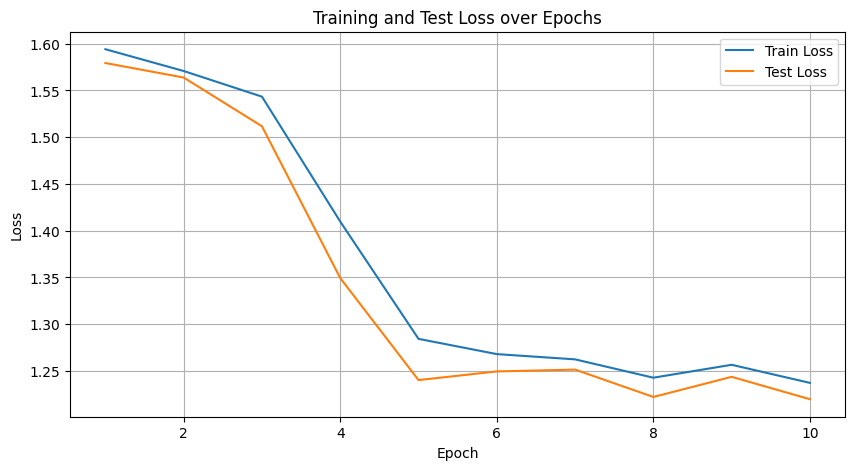

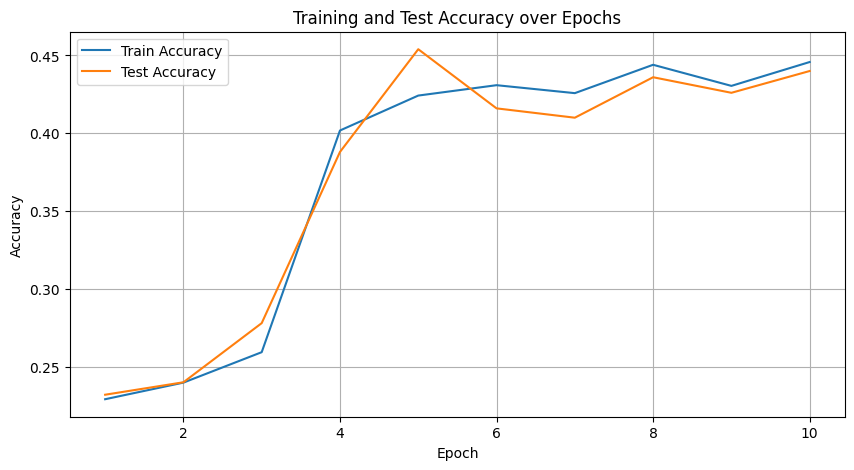

In [59]:
import matplotlib.pyplot as plt

epochs = range(1, len(metrics_dict['train_losses']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, metrics_dict['train_losses'], label='Train Loss')
plt.plot(epochs, metrics_dict['test_losses'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, metrics_dict['train_accuracies'], label='Train Accuracy')
plt.plot(epochs, metrics_dict['test_accuracies'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [60]:
from time import perf_counter
print("lstm")

start=perf_counter()
metrics_dict = run_experiment(
    model_gen=lambda: RNN(vocab_size=len(VOCAB), is_lstm=True),
    optim_gen=lambda x: torch.optim.Adam(x.parameters(), lr=0.001),
    seed=42,
    n_epochs=10,
    max_batches=None,
    verbose=True,
    device="cuda",
)
print(f"ran {perf_counter()-start} seconds")

lstm
Epoch 0 train: loss = 1.3642, accuracy = 0.4024
Epoch 0 test: loss = 1.0024, accuracy = 0.6380
Epoch 1 train: loss = 0.7175, accuracy = 0.7313
Epoch 1 test: loss = 0.4790, accuracy = 0.8440
Epoch 2 train: loss = 0.2945, accuracy = 0.9082
Epoch 2 test: loss = 0.2350, accuracy = 0.9280
Epoch 3 train: loss = 0.1839, accuracy = 0.9353
Epoch 3 test: loss = 0.3597, accuracy = 0.8860
Epoch 4 train: loss = 0.1684, accuracy = 0.9449
Epoch 4 test: loss = 0.1220, accuracy = 0.9620
Epoch 5 train: loss = 0.1118, accuracy = 0.9622
Epoch 5 test: loss = 0.1232, accuracy = 0.9660
Epoch 6 train: loss = 0.0888, accuracy = 0.9729
Epoch 6 test: loss = 0.0833, accuracy = 0.9780
Epoch 7 train: loss = 0.0619, accuracy = 0.9836
Epoch 7 test: loss = 0.0897, accuracy = 0.9700
Epoch 8 train: loss = 0.0597, accuracy = 0.9802
Epoch 8 test: loss = 0.0670, accuracy = 0.9760
Epoch 9 train: loss = 0.0483, accuracy = 0.9856
Epoch 9 test: loss = 0.0581, accuracy = 0.9860
ran 250.03381794799998 seconds


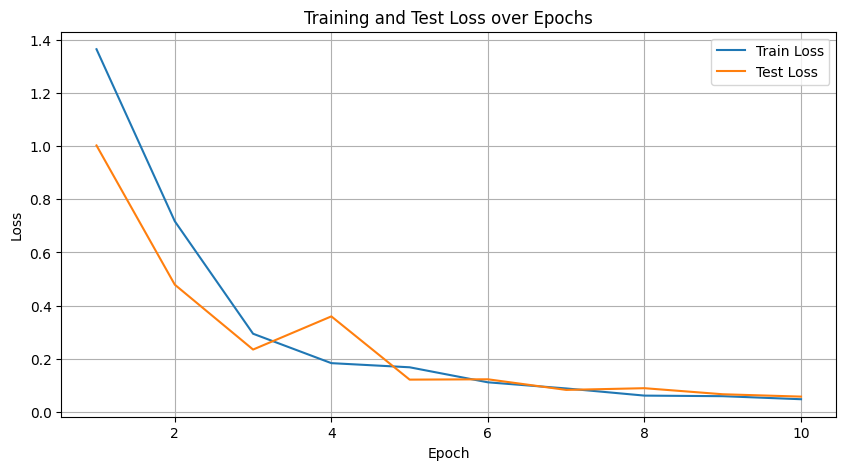

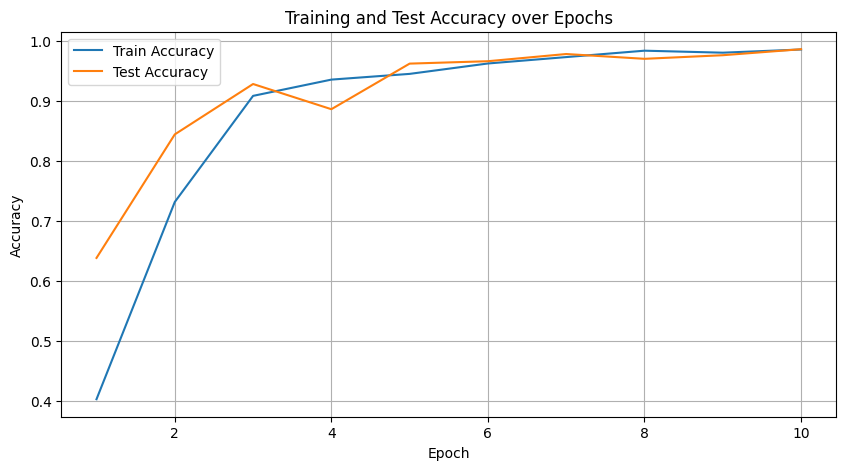

In [61]:
import matplotlib.pyplot as plt

epochs = range(1, len(metrics_dict['train_losses']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, metrics_dict['train_losses'], label='Train Loss')
plt.plot(epochs, metrics_dict['test_losses'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, metrics_dict['train_accuracies'], label='Train Accuracy')
plt.plot(epochs, metrics_dict['test_accuracies'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()


Версия с LSTM работает на порядок дольше, но как в loss, так и в accuracy мгновенно происходит скачок. Наверное, дело в том, что модель научилась запоминать характерные буквы на характерных позициях.

#### Задание 2 (8 баллов + 4 бонусных). Генерация антител

Поиграем за B-лимфоцит и попробуем создать новые антитела.

Модель - почти полная копия модели с практики, но есть дополнительное условие: теперь кроме текущего токена и предыдущего скрытого состояния пусть наша ячейка принимает ещё метку биологического вида, к которому должно относиться антитело, вроде такого:

In [62]:
class ConditionalRNNCell(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int) -> None:
        super().__init__()
        # replace 2nd hidden_dim with C_dim?
        self.linear = nn.Linear(input_dim + hidden_dim + hidden_dim, hidden_dim)

    """
    (x_{t}, h_{t-1}, c) -> h_{t}
    """
    def forward(self, x: Tensor, c: Tensor, h: Tensor) -> Tensor:
        # x: B x input_dim: эмбеддинг последнего токен
        # c: B x class_dim: эмбеддинг биологического вида
        # h: B x hidden_dim: последнее скрытое состояние
        h = torch.cat([x, h, c], dim=1)
        h = self.linear(h)
        return F.tanh(h)


import torch.nn as nn
from typing import Literal

class RNNGen(nn.Module):
    def __init__(
        self, vocab_size: int, hidden_dim: int = 64, n_classes: int = 5
    ) -> None:
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_dim)
        self.embed_c = nn.Embedding(n_classes, hidden_dim)
        self.init_h = nn.Parameter(data=torch.randn(1, hidden_dim))
        self.rnn = ConditionalRNNCell(hidden_dim, hidden_dim)
        self.lm_head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x: Tensor, c: Tensor) -> Tensor:
        # x: B x T
        # embed(x): B x T -> B x T x hidden_dim
        B, T = x.shape

        x = self.embed(x)  # B x T x hidden_dim
        c = self.embed_c(c).expand((B, -1))  # B x hidden_dim
        h = self.init_h.expand((B, -1)) # B x hidden_dim

        logits = []
        for t in range(T):
            xt = x[:, t, :] # B x hidden
            h = self.rnn.forward(xt, c, h)  # B x hidden
            y = self.lm_head(h).unsqueeze(1)  # B x 1 x hidden
            logits.append(y)

        return torch.cat(logits, dim=1)

tokens, labels = next(iter(train_loader))
print("Tokens shape: ", tokens.shape, "\nLabels shape: ", labels.shape)
# print(tokens)
# print(labels)
model = RNNGen(
    vocab_size=len(VOCAB),
)
print("vocab", len(VOCAB))
logits = model.forward(tokens, labels)
print("Logits shape: ", logits.shape)
# torch.nn.CrossEntropyLoss()(model.forward(tokens, labels), )
# no errors, nice

Tokens shape:  torch.Size([32, 131]) 
Labels shape:  torch.Size([32])
vocab 24
Logits shape:  torch.Size([32, 131, 24])


**2.1. (2 балла)** Реализуйте архитектуру модели для генерации антител символ за символом

**2.2. (2 балла)** Обучите модель в течение 10-50 эпох, постройте графики функции ошибки.

**2.3. (4 балла)** Сгенерируйте с помощью модели по 20 антител для каждого биологического вида в отдельных ячейках, выведите их в ноутбуке. Воспользуйтесь функцией `get_sequence_score` (ниже), чтобы посчитать сходство ваших антител с природными (вернее - очень грубую оценку). Посчитайте, сколько антител из сгенерированных вами имеют оценку 0.55 и выше для каждого биологического вида.

**2.4. (Бонус 4 балла)** Повторите пункты 2.2 и 2.3, но используйте другой тип рекуррентной ячейки (GRU или LSTM).


In [63]:
# print(len(VOCAB))
F.cross_entropy(
    logits[:, :-1].reshape(-1, len(VOCAB)),
    tokens[:, 1:].reshape(-1),
)

tensor(3.2295, grad_fn=<NllLossBackward0>)

In [67]:
@torch.no_grad()
def generate(model: RNNGen, idx: Tensor, c: Tensor, max_new_tokens: int) -> Tensor:
    # idx: B x T
    for t in range(max_new_tokens):
        logits = model.forward(idx, c)[:, -1]  # B x T x V
        probs = F.softmax(logits, dim=1)  # B x V
        new_token = torch.multinomial(probs, 1)
        idx = torch.cat([idx, new_token], dim=1)

    return idx

def batch_decode(out_tokens: Tensor) -> list[str]:
    decoded_strings = []
    for x in out_tokens:
        decoded_strings.append(decode_tokens(x.tolist(), remove_special_tokens=True))

    return decoded_strings


samples = generate(model, idx=torch.full(size=(4, 1), fill_value=1, dtype=int),
    c=torch.full(size=(4,), fill_value=1, dtype=int), max_new_tokens=max_length_dict[ANTISPECIES[1]])
print('\n'.join(batch_decode(samples)))

FPNXYXLNTNALXQYKIGLXLAQQMSEDHVWPRVKAAYAKXATQIHQCKTYFFCYGYYMXYREIAFPNAKLYPRKFNIFRNRXTALSEQDPQCCTGLLNGMTCAQPRX
NALAHGQFKGWVGIIIXDWPSFDTRFRYAGPDKKNEKDRWTKVMEEEPLHIVKFYPEAITQFPQCRFCKTXHVEQFRPSHAANGRLMQYXCTKHYAEEICDP
MPYFRMFNEVCCIIIHFHHTVEQHEKMLLTKACEEVVHHDASQIXTVSTREPNCYGEYRRCNAWMGHXXQIMDDRKKNFKMYTHSMKLWFFXKENRPLLRTNKFELESVPEQ
EKQFXSQXGVMKELGCQYDXRALSFYTCPSPVQLNTQYEIQXWNFEDHKQVKTHFHYDQEDTNIEAHIXWLVETNXFVMGXKINPKXHREHDAAFXETFFSREKGGQDMXPHV


In [81]:
from collections import defaultdict
from typing import Callable

import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def training_step(
    batch: tuple[torch.Tensor, torch.Tensor],
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: str = "cpu",
) -> tuple[Tensor, Tensor]:
    model.to(device=device)
    # прогоняем батч через модель
    x, y = batch
    logits = model(x.to(device=device), y.to(device=device))
    tokens = x.to(device=device)
    # оцениваем значение ошибки
    preds = logits[:, :-1].reshape(-1, len(VOCAB))
    targets = tokens[:, 1:].reshape(-1)
    loss = F.cross_entropy(preds, targets)
    # обновляем параметры
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    # возвращаем значение функции ошибки для логирования
    return loss, preds, targets


def train_epoch(
    dataloader: DataLoader,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    max_batches: int = 100,
    device: str = "cpu",
) -> dict[str, float]:
    model.train()
    loss_total = 0
    n_correct = 0
    n_total = 0
    for i, batch in enumerate(dataloader):
        x, y = batch
        loss, preds, targets = training_step(batch, model, optimizer, device)

        # save stats
        n_total += targets.size(0)
        # print('n_total += ', targets.size(0))
        n_correct += (targets.to(device=device) == preds.argmax(dim=1)).sum()
        # print('n_correct += ', (targets.to(device=device) == preds.argmax(dim=1)).sum())
        loss_total += targets.size(0) * loss.item()
        if i == max_batches:
            break

    return {
        "loss": loss_total / n_total,
        "accuracy": n_correct / n_total,
    }


@torch.no_grad()
def test_epoch(
    dataloader: DataLoader,
    model: nn.Module,
    max_batches: int = 100,
    device: str = "cpu",
) -> Tensor:
    model.eval()
    model.to(device=device)
    loss_total = 0
    n_correct = 0
    n_total = 0
    for i, batch in enumerate(dataloader):
        # прогоняем батч через модель
        x, y = batch
        logits = model(x.to(device=device), y.to(device=device))
        tokens = x.to(device=device)
        # оцениваем значение ошибки
        preds = logits[:, :-1].reshape(-1, len(VOCAB))
        targets = tokens[:, 1:].reshape(-1)
        loss = F.cross_entropy(preds, targets)
        # save stats
        n_total += targets.size(0)
        n_correct += (targets.to(device=device) == preds.argmax(dim=1)).sum()
        # print(targets.to(device=device), preds.argmax(dim=1))
        loss_total += targets.size(0) * loss.item()
        if i == max_batches:
            break

    return {
        "loss": loss_total / n_total,
        "accuracy": n_correct / n_total,
    }


def run_experiment(
    model_gen: Callable[[], nn.Module],
    optim_gen: Callable[[nn.Module], torch.optim.Optimizer],
    seed: int,
    n_epochs: int = 10,
    max_batches: int | None = None,
    verbose: bool = False,
    device: str = "cpu",
) -> dict[str, list[float]]:
    torch.manual_seed(seed)
    model = model_gen()
    optim = optim_gen(model)
    metrics: dict[str, list[float]] = defaultdict(list)
    for i in range(n_epochs):
        train_dict = train_epoch(
            train_loader, model, optim, max_batches=max_batches, device=device
        )
        test_dict = test_epoch(
            test_loader, model, max_batches=max_batches, device=device
        )
        train_loss, train_accuracy = train_dict["loss"], train_dict["accuracy"]
        test_loss, test_accuracy = test_dict["loss"], test_dict["accuracy"]
        if verbose:
            print(
                f"Epoch {i} train: loss = {train_loss:.4f}, accuracy = {train_accuracy:.4f}"
            )
            print(
                f"Epoch {i} test: loss = {test_loss:.4f}, accuracy = {test_accuracy:.4f}"
            )

        metrics["train_losses"].append(train_loss)
        metrics["train_accuracies"].append(train_accuracy.item())
        metrics["test_losses"].append(test_loss)
        metrics["test_accuracies"].append(test_accuracy.item())

    return metrics

In [96]:
from time import perf_counter
print("no lstm")

start=perf_counter()
model = RNNGen(vocab_size=len(VOCAB))
metrics_dict = run_experiment(
    model_gen=lambda: model,
    optim_gen=lambda x: torch.optim.Adam(x.parameters(), lr=0.001),
    seed=42,
    n_epochs=20,
    max_batches=None,
    verbose=True,
    device="cuda",
)
print(f"ran {perf_counter()-start} seconds")

no lstm
Epoch 0 train: loss = 2.2912, accuracy = 0.3349
Epoch 0 test: loss = 1.8341, accuracy = 0.4919
Epoch 1 train: loss = 1.6361, accuracy = 0.5559
Epoch 1 test: loss = 1.4186, accuracy = 0.6203
Epoch 2 train: loss = 1.3592, accuracy = 0.6420
Epoch 2 test: loss = 1.2397, accuracy = 0.6789
Epoch 3 train: loss = 1.2255, accuracy = 0.6811
Epoch 3 test: loss = 1.1568, accuracy = 0.7002
Epoch 4 train: loss = 1.1524, accuracy = 0.7006
Epoch 4 test: loss = 1.0914, accuracy = 0.7195
Epoch 5 train: loss = 1.1043, accuracy = 0.7131
Epoch 5 test: loss = 1.0557, accuracy = 0.7277
Epoch 6 train: loss = 1.0694, accuracy = 0.7219
Epoch 6 test: loss = 1.0363, accuracy = 0.7310
Epoch 7 train: loss = 1.0521, accuracy = 0.7262
Epoch 7 test: loss = 1.0144, accuracy = 0.7385
Epoch 8 train: loss = 1.0286, accuracy = 0.7326
Epoch 8 test: loss = 0.9942, accuracy = 0.7448
Epoch 9 train: loss = 1.0108, accuracy = 0.7374
Epoch 9 test: loss = 0.9797, accuracy = 0.7463
Epoch 10 train: loss = 0.9976, accuracy = 

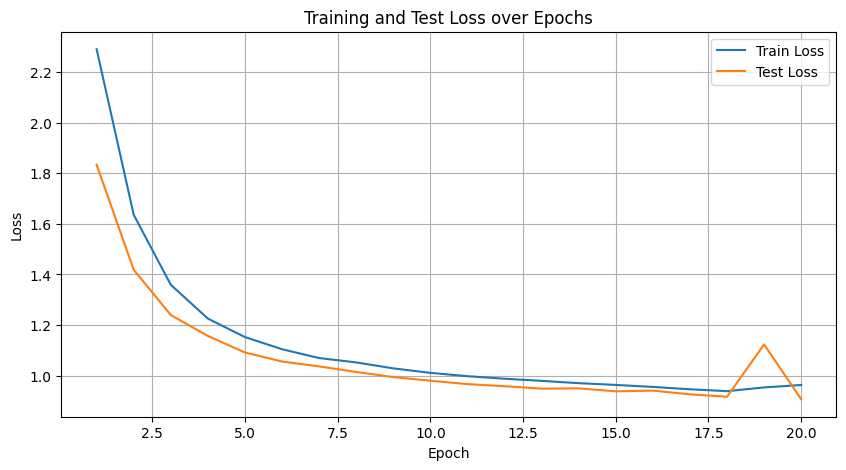

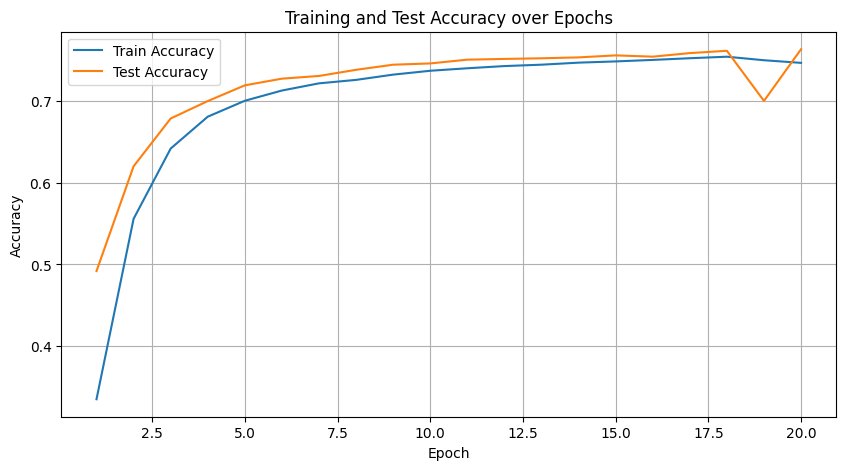

In [97]:
import matplotlib.pyplot as plt

epochs = range(1, len(metrics_dict['train_losses']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, metrics_dict['train_losses'], label='Train Loss')
plt.plot(epochs, metrics_dict['test_losses'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, metrics_dict['train_accuracies'], label='Train Accuracy')
plt.plot(epochs, metrics_dict['test_accuracies'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [84]:
! pip install biopython==1.84

In [85]:
from Bio.Align import PairwiseAligner


def get_sequence_score(query_sequence: str) -> float:
    references = [
        "QVQLQQPGAELVKPGASVKMSCKAS_WITWVKQRPGQGLEWIGDI_TNYNEKFKTKATLTVDTSSSTAYMQLSSLTSEDSAVYYCAR_WGQGTSVTVSS",
        "EVKLEESGGGLVQPGGSMKLSCAAS_WMDWVRQSPEKGLEWVAEI_TYYAESVKGRFTISRDDSKSSVYLQMNSLRAEDTGIYYCTA_WGQGTLVTVSA",
        "HVQLVESGGGSVQPGGSLRLSCTVS_CMGWFRRAPGKEREKVATL_TSYADSVKGRFAISQDPAKNTLWLQMNSLKPEDSATYYCAA_SSRGTQVTVS",
        "QVQLVESGGGSVQAGGSLKLSCAAS_CMGWSRQAPGKGREGVARI_TAYADSVKGRFTISHDSIKNTLYLQMNSLRPEDTAKYYCAA_WGQGTQVTV",
        "QSLEESGGDLVKPGASLTLTCTAS_YMCWVRQAPGKGLEWIACI_TYYASWAKGRFTISKTSSTTVTLQMTSLTAADTATYFCAS_WGQGTLVTVS",
        "QEQLVESGGGLVKPGASLTLTCKAS_VMCWVRQAPGKGLEWIACI_SVYASWAKGRSTISRTSSTTVTLQMTSLTAADTATYFCAR_RGPGTLVTVS",
        "SVKVSCKAS_WIQWVRQAPGQGLEWMGWM_TTYSPKFQGRVSMTSDKSITTAYLELRGLTSDDTAVYSCAR_WGQGTLITVTS",
    ]
    max_score = 0.0
    for ref in map(lambda s: s.replace("_", ""), references):
        alignment = PairwiseAligner().align(query_sequence, ref)[0]
        n_matches = sum(
            1 for i in range(alignment.length) if alignment[0][i] == alignment[1][i]
        )
        max_score = max(max_score, n_matches / len(ref))

    return max_score

In [86]:
get_sequence_score("SVKVSCKAPEDNYSDYWGQGTGTTVTVSS")

0.3

In [98]:
for s in SPECIES.values():
    samples = generate(model, idx=torch.full(size=(20, 1), fill_value=1, dtype=int).to('cuda'),
        c=torch.full(size=(20,), fill_value=s, dtype=int).to('cuda'), max_new_tokens=max_length_dict[ANTISPECIES[s]])
    mean_score = 0
    mt055 = 0
    for sample in samples:
        word = decode_tokens(sample.tolist(), remove_special_tokens=True)
        score = get_sequence_score(word)
        mean_score += score
        mt055 += 1 if score >= 0.55 else 0

    mean_score /= len(samples)
    mt055 /= len(samples)
    print(ANTISPECIES[s], 'mean score: ', mean_score, 'proportion with score >= 0.55: ', mt055)
    #print('\n'.join(batch_decode(samples)))

Camel mean score:  0.48678723178484995 proportion with score >= 0.55:  0.4
Human mean score:  0.4800742107069322 proportion with score >= 0.55:  0.35
Mouse mean score:  0.449731182795699 proportion with score >= 0.55:  0.25
Rabbit mean score:  0.4445683196064974 proportion with score >= 0.55:  0.3
Rhesus mean score:  0.544611001487074 proportion with score >= 0.55:  0.55


In [99]:
class ConditionalLSTMCell(nn.Module):
    """
    (x_{t}, h_{t-1}) -> h_{t}
    """

    def __init__(self, input_dim: int, hidden_dim: int) -> None:
        super().__init__()
        self.linear_f = nn.Linear(input_dim + hidden_dim + hidden_dim, hidden_dim)
        self.linear_i = nn.Linear(input_dim + hidden_dim + hidden_dim, hidden_dim)
        self.linear_c = nn.Linear(input_dim + hidden_dim + hidden_dim, hidden_dim)
        self.linear_o = nn.Linear(input_dim + hidden_dim + hidden_dim, hidden_dim)

    def forward(self, x: Tensor, h: Tensor, c: Tensor, C: Tensor) -> Tensor:
        f = torch.sigmoid(self.linear_f(torch.cat([x, h, c], dim=1)))
        i = torch.sigmoid(self.linear_i(torch.cat([x, h, c], dim=1)))
        C_ = F.tanh(self.linear_c(torch.cat([x, h, c], dim=1)))
        C = f * C + i * C_
        o = torch.sigmoid(self.linear_o(torch.cat([x, h, c], dim=1)))
        return o * F.tanh(C), C

import torch.nn as nn
from typing import Literal

class RNNGenLSTM(nn.Module):
    def __init__(
        self, vocab_size: int, hidden_dim: int = 64, n_classes: int = 5
    ) -> None:
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_dim)
        self.embed_c = nn.Embedding(n_classes, hidden_dim)
        self.init_h = nn.Parameter(data=torch.randn(1, hidden_dim))
        self.lstm = ConditionalLSTMCell(hidden_dim, hidden_dim)
        self.lm_head = nn.Linear(hidden_dim, vocab_size)
        self.init_C = nn.Parameter(data=torch.randn(1, hidden_dim))

    def forward(self, x: Tensor, c: Tensor) -> Tensor:
        # x: B x T
        # embed(x): B x T -> B x T x hidden_dim
        B, T = x.shape

        x = self.embed(x)  # B x T x hidden_dim
        c = self.embed_c(c).expand((B, -1))  # B x hidden_dim
        h = self.init_h.expand((B, -1)) # B x hidden_dim

        C = self.init_C.expand((B, -1))

        logits = []
        for t in range(T):
            xt = x[:, t, :] # B x hidden
            h, C = self.lstm.forward(xt, h, c, C)
            y = self.lm_head(h).unsqueeze(1)  # B x 1 x hidden
            logits.append(y)

        return torch.cat(logits, dim=1)

tokens, labels = next(iter(train_loader))
print("Tokens shape: ", tokens.shape, "\nLabels shape: ", labels.shape)
# print(tokens)
# print(labels)
model = RNNGen(
    vocab_size=len(VOCAB),
)
print("vocab", len(VOCAB))
logits = model.forward(tokens, labels)
print("Logits shape: ", logits.shape)
# torch.nn.CrossEntropyLoss()(model.forward(tokens, labels), )
# no errors, nice

Tokens shape:  torch.Size([32, 129]) 
Labels shape:  torch.Size([32])
vocab 24
Logits shape:  torch.Size([32, 129, 24])


In [101]:
from time import perf_counter
print("lstm")

start=perf_counter()
model = RNNGenLSTM(vocab_size=len(VOCAB))
metrics_dict = run_experiment(
    model_gen=lambda: model,
    optim_gen=lambda x: torch.optim.Adam(x.parameters(), lr=0.001),
    seed=42,
    n_epochs=10,
    max_batches=None,
    verbose=True,
    device="cuda",
)
print(f"ran {perf_counter()-start} seconds")

lstm
Epoch 0 train: loss = 2.2751, accuracy = 0.3441
Epoch 0 test: loss = 1.7218, accuracy = 0.5229
Epoch 1 train: loss = 1.5119, accuracy = 0.6002
Epoch 1 test: loss = 1.2958, accuracy = 0.6686
Epoch 2 train: loss = 1.2325, accuracy = 0.6869
Epoch 2 test: loss = 1.1281, accuracy = 0.7163
Epoch 3 train: loss = 1.1064, accuracy = 0.7205
Epoch 3 test: loss = 1.0302, accuracy = 0.7404
Epoch 4 train: loss = 1.0300, accuracy = 0.7373
Epoch 4 test: loss = 0.9749, accuracy = 0.7502
Epoch 5 train: loss = 0.9779, accuracy = 0.7483
Epoch 5 test: loss = 0.9295, accuracy = 0.7593
Epoch 6 train: loss = 0.9468, accuracy = 0.7549
Epoch 6 test: loss = 0.9065, accuracy = 0.7647
Epoch 7 train: loss = 0.9195, accuracy = 0.7612
Epoch 7 test: loss = 0.9345, accuracy = 0.7544
Epoch 8 train: loss = 0.9032, accuracy = 0.7641
Epoch 8 test: loss = 0.8612, accuracy = 0.7747
Epoch 9 train: loss = 0.8727, accuracy = 0.7716
Epoch 9 test: loss = 0.8455, accuracy = 0.7787
ran 297.01729999800045 seconds


In [103]:
from time import perf_counter
print("lstm+10 epochs")

start=perf_counter()
metrics_dict = run_experiment(
    model_gen=lambda: model,
    optim_gen=lambda x: torch.optim.Adam(x.parameters(), lr=0.001),
    seed=42,
    n_epochs=10,
    max_batches=None,
    verbose=True,
    device="cuda",
)
print(f"ran {perf_counter()-start} seconds")

lstm+10 epochs
Epoch 0 train: loss = 0.8592, accuracy = 0.7744
Epoch 0 test: loss = 0.8311, accuracy = 0.7815
Epoch 1 train: loss = 0.8441, accuracy = 0.7779
Epoch 1 test: loss = 0.8195, accuracy = 0.7837
Epoch 2 train: loss = 0.8418, accuracy = 0.7779
Epoch 2 test: loss = 0.8270, accuracy = 0.7808
Epoch 3 train: loss = 0.8283, accuracy = 0.7815
Epoch 3 test: loss = 0.8091, accuracy = 0.7856
Epoch 4 train: loss = 0.8140, accuracy = 0.7851
Epoch 4 test: loss = 0.7951, accuracy = 0.7897
Epoch 5 train: loss = 0.8055, accuracy = 0.7874
Epoch 5 test: loss = 0.7894, accuracy = 0.7918
Epoch 6 train: loss = 0.7982, accuracy = 0.7889
Epoch 6 test: loss = 0.7828, accuracy = 0.7938
Epoch 7 train: loss = 0.7933, accuracy = 0.7902
Epoch 7 test: loss = 0.7795, accuracy = 0.7943
Epoch 8 train: loss = 0.7873, accuracy = 0.7916
Epoch 8 test: loss = 0.7746, accuracy = 0.7952
Epoch 9 train: loss = 0.7820, accuracy = 0.7931
Epoch 9 test: loss = 0.7700, accuracy = 0.7962
ran 294.53052379700057 seconds


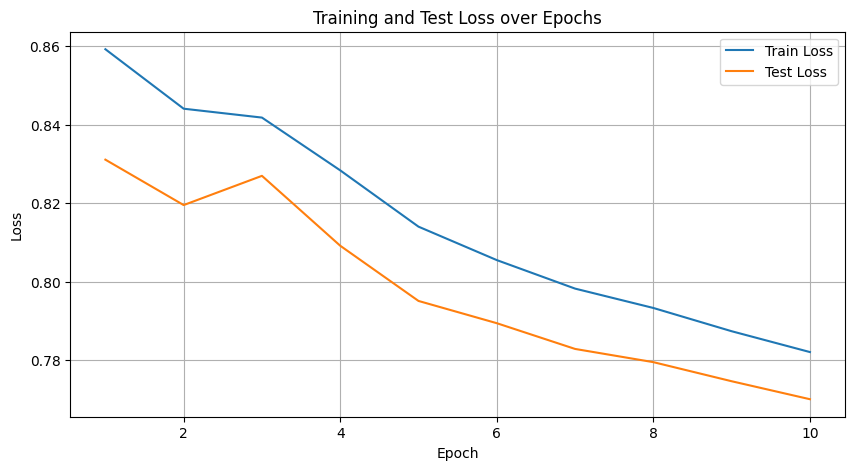

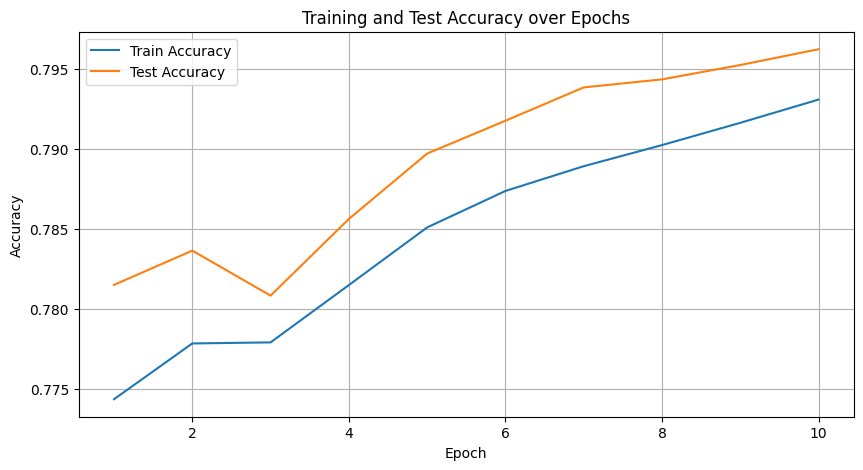

In [104]:
import matplotlib.pyplot as plt

epochs = range(1, len(metrics_dict['train_losses']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, metrics_dict['train_losses'], label='Train Loss')
plt.plot(epochs, metrics_dict['test_losses'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, metrics_dict['train_accuracies'], label='Train Accuracy')
plt.plot(epochs, metrics_dict['test_accuracies'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [112]:
all_samples = {}
for s in SPECIES.values():
    samples = generate(model, idx=torch.full(size=(20, 1), fill_value=1, dtype=int).to('cuda'),
        c=torch.full(size=(20,), fill_value=s, dtype=int).to('cuda'), max_new_tokens=max_length_dict[ANTISPECIES[s]])
    all_samples[s] = samples
    mean_score = 0
    mt055 = 0
    for sample in samples:
        word = decode_tokens(sample.tolist(), remove_special_tokens=True)
        score = get_sequence_score(word)
        mean_score += score
        mt055 += 1 if score >= 0.55 else 0

    mean_score /= len(samples)
    mt055 /= len(samples)
    print(ANTISPECIES[s], 'mean score: ', mean_score, 'proportion with score >= 0.55: ', mt055)

Camel mean score:  0.7458342665173573 proportion with score >= 0.55:  0.9
Human mean score:  0.6885416666666667 proportion with score >= 0.55:  0.9
Mouse mean score:  0.718125 proportion with score >= 0.55:  1.0
Rabbit mean score:  0.7341233413406543 proportion with score >= 0.55:  0.8
Rhesus mean score:  0.6237042438801189 proportion with score >= 0.55:  1.0


In [124]:
print("sample examples by species:")
for s in SPECIES.values():
    sample = all_samples[s][torch.randint(0, 20, (1,)).item()]
    print(ANTISPECIES[s], decode_tokens(sample.tolist(), remove_special_tokens=True))

sample examples by species:
Camel HVQLVESGGGSVQAGGSLTLSCVGSGFSVSDSEFYWGRQAPEDEREGVATITVGGGRTAYADSVKGRFTISQDNAKKSITLYLQMNSLKPEDTAMYYCATAGRGGICRACYLRWGQGTQVTVS
Human QVQLQQSGPVLVQPGASVKMSCKASGYTFTSYNWIKEWGRPQPQTLRLSSSWISDRNTNNSIKSTLTADTDSARSLKLNDLQPEDSVTYYCGSDSWYNLAAWGTQVTLTSKS
Mouse SVKVSCKASGYTFTNDYAMNWVRQAPGQGLEWMGGIIPNYNNGNYAQKFRGRVTMTRDTSTSTVYMELSRLRSEDTAVYYCARGGGFDVYSWGQGTLVTVSS
Rabbit EQTEGGLVKPGASLTLTCKASGFSFSNNKASEVRLARPGEGLEGIVSAYIDNIVYAKAYSKARFTVSSSSTTVTVQMTSLTAADTATYFCARDTYTSTTTTFTWANGFFYLTWAQGRFTISLSTAAQLT
Rhesus QVQLQESGPGLVKPSETLSLTCAVSGGSISSYYWTWRRQPPGKGLEWVGCISGDGGGYNPLWFRQRPREALTITSSSGATATRVQSVKNTAASAAYYSLTGFSSLDPSTLASLWSRAVSAGYHFHVWGPG
